# 02 — Reproduce Karp+ 2023 in TNG100-1 (h^-1 units)

Sanity check that our TNG100-1 pipeline reproduces
[Karp, Lange & Wechsler (2023, ApJL 949, L13)](https://iopscience.iop.org/article/10.3847/2041-8213/acd3e9):
the satellite **quenched fraction vs host halo mass** and the **relative satellite count vs
azimuthal angle** (their Fig. 1 / Fig. 4 style).

**The whole point of this notebook is the little-h convention.** Karp+ select
`M_200c > 10^12 h^-1 M_sun` and `M*,sat >= 10^8 h^-1 M_sun`. TNG masses are already in
`10^10 h^-1 M_sun`, so here we multiply by `1e10` and **do NOT divide by h**. (Dividing by h —
as some earlier cells did — shifts log-mass by +0.17 dex and is exactly why the masses didn't
line up before.) For the fiducial *science* catalogs in physical M_sun, use
`01_tng_generate_catalogs.ipynb` instead.

**Runs only on Binder** (needs `illustris_python`, `h5py`, and the raw TNG100-1 catalogs).

In [4]:
import os
import numpy as np
import pandas as pd
import h5py
import illustris_python as il
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

## Configuration (Karp+ h^-1 selection)

In [5]:
# Pick the simulation and redshift (see notebook 01). Karp+ 2023 used TNG100 at z=0.
SIM      = 'TNG100'                 # 'TNG100' or 'TNG50'
REDSHIFT = 'z0'                     # 'z0' (snap 99) or 'z0p05' (snap 98)
_SIM_DIR    = {'TNG100': 'L75n1820TNG', 'TNG50': 'L35n2160TNG'}[SIM]
_LBOX_MPC_H = {'TNG100': 75.0,         'TNG50': 35.0}[SIM]
snap        = {'z0': 99, 'z0p05': 98}[REDSHIFT]

TNG_ROOT = os.path.expanduser(f'~/SimulationData/{_SIM_DIR}')

_sp             = f'snapnum_{snap:03d}'
basePath        = os.path.join(TNG_ROOT, 'output')
morph_g         = os.path.join(TNG_ROOT, f'postprocessing/skirt_images/sdss/{_sp}/morphs_g.hdf5')
morph_i         = os.path.join(TNG_ROOT, f'postprocessing/skirt_images/sdss/{_sp}/morphs_i.hdf5')
subfind_id_path = os.path.join(TNG_ROOT, f'postprocessing/skirt_images/sdss/{_sp}/subfind_ids.txt')

assert os.path.isdir(basePath), f'basePath does not exist: {basePath}\n  -> edit TNG_ROOT for {SIM} ({_SIM_DIR}).'
print(f'SIM = {SIM} | REDSHIFT = {REDSHIFT} (snap {snap}) | TNG_ROOT = {TNG_ROOT}')

h    = 0.6774
Lbox = _LBOX_MPC_H * 1000.0 / h     # physical kpc

# --- Karp+ 2023 selection, in h^-1 M_sun (NO division by h) ---
HOST_LOGM200_HINV_MIN = 12.0   # log10 M_200c [h^-1 M_sun]  -> M_200c > 1e12 h^-1 M_sun
SAT_LOGMSTAR_HINV_MIN = 8.0    # log10 M*,sat [h^-1 M_sun]   -> M*,sat >= 1e8 h^-1 M_sun
SN_MIN = 2.5
KARP_FQ_REF = 0.615            # Karp+ overall satellite quenched fraction

SIM = TNG100 | REDSHIFT = z0 (snap 99) | TNG_ROOT = /home/jovyan/SimulationData/L75n1820TNG


## Load catalogs

In [6]:
groups = il.groupcat.loadHalos(
    basePath, snap, fields=['GroupFirstSub', 'Group_M_Crit200', 'Group_R_Crit200', 'GroupNsubs'])
subhalos = il.groupcat.loadSubhalos(
    basePath, snap, fields=['SubhaloGrNr', 'SubhaloMassType', 'SubhaloCM', 'SubhaloSFR'])
n_sub = len(subhalos['SubhaloGrNr'])

sdss_g = h5py.File(morph_g, 'r')
sdss_i = h5py.File(morph_i, 'r')
subfind_ids = np.loadtxt(subfind_id_path)
print('subhalos:', n_sub)

subhalos: 4371211


## Select hosts (h^-1) and flag their satellites

Host mass in **h^-1 M_sun** is `Group_M_Crit200 * 1e10` (no `/h`). Satellites of a group are the
subhalos `GroupFirstSub+1 ... GroupFirstSub+GroupNsubs-1`.

In [7]:
host_logm200_hinv = np.log10(groups['Group_M_Crit200'] * 1e10)     # h^-1 M_sun, NO /h
host_sel  = host_logm200_hinv > HOST_LOGM200_HINV_MIN
first_sub = groups['GroupFirstSub'][host_sel]
n_subs    = groups['GroupNsubs'][host_sel]
print('hosts with M_200c > 1e12 h^-1 M_sun:', host_sel.sum())

sat_mask      = np.zeros(n_sub, dtype=bool)
host_id_arr   = np.full(n_sub, -1, dtype=int)
host_center   = np.zeros((n_sub, 3))
host_m200     = np.zeros(n_sub)        # log10 M_200c h^-1
m200_sel = host_logm200_hinv[host_sel]

for k in range(len(first_sub)):
    c  = first_sub[k]
    sl = slice(c + 1, c + n_subs[k])
    sat_mask[sl]    = True
    host_id_arr[sl] = k
    host_center[sl] = subhalos['SubhaloCM'][c] / h
    host_m200[sl]   = m200_sel[k]
print('satellite subhalos:', sat_mask.sum())

hosts with M_200c > 1e12 h^-1 M_sun: 1243
satellite subhalos: 466614


/tmp/ipykernel_663/1140512782.py:1: RuntimeWarning: divide by zero encountered in log10
  host_logm200_hinv = np.log10(groups['Group_M_Crit200'] * 1e10)     # h^-1 M_sun, NO /h


## Host Sersic orientation + quality flags (SDSS g/i), broadcast to satellites

In [8]:
def host_morph_to_satellites(sdss, first_sub, n_subs, subfind_ids, n_sub):
    theta = np.zeros(n_sub); flag = np.zeros(n_sub); sflag = np.zeros(n_sub); sn = np.zeros(n_sub)
    theta_all = np.asarray(sdss['sersic_theta']) * 180.0 / np.pi
    flag_all  = np.asarray(sdss['flag'])
    sflag_all = np.asarray(sdss['flag_sersic'])
    sn_all    = np.asarray(sdss['sn_per_pixel'])
    for k in range(len(first_sub)):
        c = first_sub[k]; row = np.where(subfind_ids == c)[0]
        if row.size == 0:
            flag[c + 1:c + n_subs[k]] = 1
            continue
        r = row[0]; sl = slice(c + 1, c + n_subs[k])
        theta[sl] = theta_all[r]; flag[sl] = flag_all[r]
        sflag[sl] = sflag_all[r]; sn[sl] = sn_all[r]
    return theta, flag, sflag, sn

theta_g, flag_g, sflag_g, sn_g = host_morph_to_satellites(sdss_g, first_sub, n_subs, subfind_ids, n_sub)
theta_i, flag_i, sflag_i, sn_i = host_morph_to_satellites(sdss_i, first_sub, n_subs, subfind_ids, n_sub)
host_theta = 0.5 * (theta_g + theta_i)
host_good  = ((flag_g == 0) & (sflag_g == 0) & (sn_g > SN_MIN) &
              (flag_i == 0) & (sflag_i == 0) & (sn_i > SN_MIN))

## Masses (h^-1), SFR, quenched flag, and azimuthal angle

In [9]:
def wrap_min_image(d, L):
    return d - L * np.round(d / L)

def angle_from_major_axis(phi_sat_deg, pa_host_deg):
    phi = np.mod(phi_sat_deg, 360.0)
    d1 = np.abs(phi - np.mod(pa_host_deg, 360.0))
    d2 = np.abs(phi - np.mod(pa_host_deg + 180.0, 360.0))
    d1 = np.minimum(d1, 360.0 - d1); d2 = np.minimum(d2, 360.0 - d2)
    m  = np.minimum(d1, d2)
    return np.minimum(m, 180.0 - m)

mstar_hinv = np.log10(subhalos['SubhaloMassType'][:, 4] * 1e10)       # h^-1 M_sun (for the Karp cut)
mstar_phys = np.log10(subhalos['SubhaloMassType'][:, 4] * 1e10 / h)   # physical M_sun (for the SFMS)
sat_sfr    = np.asarray(subhalos['SubhaloSFR'])

rel    = wrap_min_image(subhalos['SubhaloCM'] / h - host_center, Lbox)
phi_2d = np.degrees(np.arctan2(rel[:, 1], rel[:, 0]))
alpha  = angle_from_major_axis(phi_2d, host_theta)

# quenched: 1 dex below the SFMS (Martin-Navarro+ 2021). NOTE: the MN21 SFMS fit is calibrated in
# PHYSICAL stellar mass, so the quench classification uses mstar_phys even though the Karp+ sample
# SELECTION (below) is in h^-1 units.
def quenched_flag(logmstar_phys, sfr):
    return (sfr < 10.0 ** (0.75 * logmstar_phys - 7.5) / 10.0).astype(int)

# Karp+ satellite sample (selection cut in h^-1 M_sun)
sel = sat_mask & host_good & (mstar_hinv >= SAT_LOGMSTAR_HINV_MIN)
print('Karp-selection satellites:', sel.sum(), '| hosts:', np.unique(host_id_arr[sel]).size)

/tmp/ipykernel_663/3948152929.py:12: RuntimeWarning: divide by zero encountered in log10
  mstar_hinv = np.log10(subhalos['SubhaloMassType'][:, 4] * 1e10)       # h^-1 M_sun (for the Karp cut)
/tmp/ipykernel_663/3948152929.py:13: RuntimeWarning: divide by zero encountered in log10
  mstar_phys = np.log10(subhalos['SubhaloMassType'][:, 4] * 1e10 / h)   # physical M_sun (for the SFMS)


Karp-selection satellites: 15065 | hosts: 982


## Figure 1a — quenched fraction vs host halo mass

Karp+ report an overall satellite quenched fraction f_q ~ 0.615 across the full halo-mass range.
The dashed line is that reference.

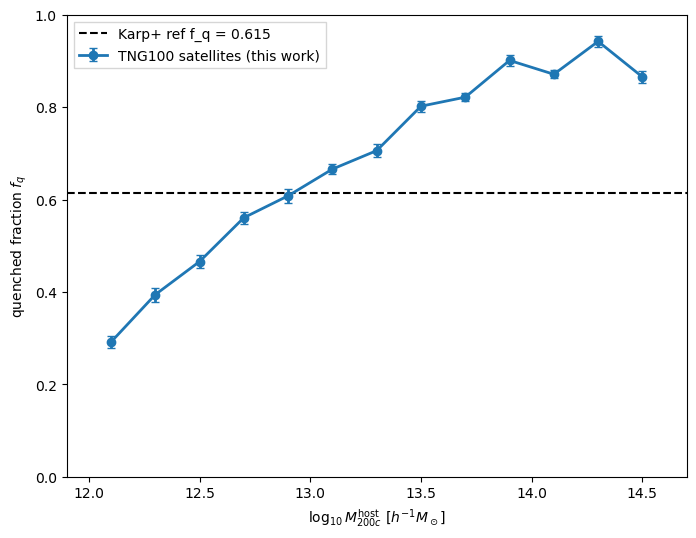

overall f_q (Karp selection) = 0.662  (Karp+ ref ~ 0.615)


In [10]:
fq = quenched_flag(mstar_phys[sel], sat_sfr[sel])
mean, edges, _ = binned_statistic(host_m200[sel], fq, statistic='mean', bins=13, range=[12, 14.6])
cnt,  _, _     = binned_statistic(host_m200[sel], fq, statistic='count', bins=13, range=[12, 14.6])
ctr = 0.5 * (edges[:-1] + edges[1:])
err = np.sqrt(mean * (1 - mean) / np.where(cnt > 0, cnt, np.nan))

plt.figure(figsize=(8, 6))
plt.errorbar(ctr, mean, yerr=err, marker='o', capsize=3, lw=2, label='TNG100 satellites (this work)')
plt.axhline(KARP_FQ_REF, color='k', ls='--', label=f'Karp+ ref f_q = {KARP_FQ_REF}')
plt.xlabel(r'$\log_{10} M_{200c}^{\rm host}\ [h^{-1}M_\odot]$')
plt.ylabel(r'quenched fraction $f_q$')
plt.xlim(11.9, 14.7); plt.ylim(0, 1); plt.legend(fancybox=False); plt.show()

print(f'overall f_q (Karp selection) = {fq.mean():.3f}  (Karp+ ref ~ {KARP_FQ_REF})')

## Figure 1b — relative satellite count vs azimuthal angle

Overplotted on Karp+'s digitized points (their Fig. 4). Agreement here is the direct test that
our masses/selection match Karp+.

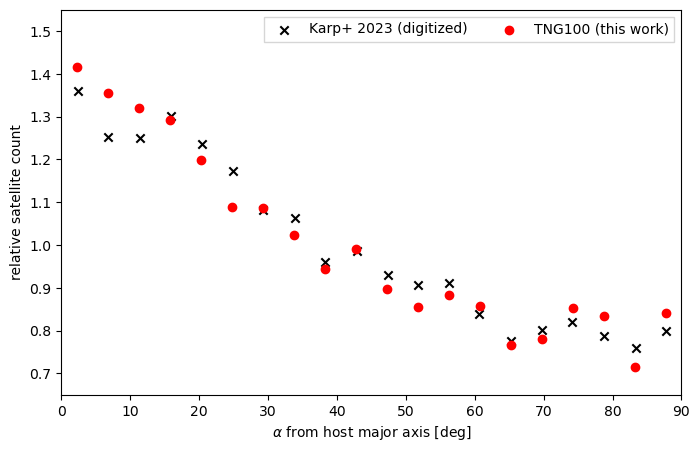

In [11]:
# Karp+ 2023 digitized relative-count points (angle [deg], relative count)
karp_data = np.array([
    [2.443, 1.361], [6.770, 1.253], [11.353, 1.250], [15.955, 1.301], [20.407, 1.237],
    [24.858, 1.173], [29.299, 1.081], [33.876, 1.062], [38.314, 0.961], [42.907, 0.985],
    [47.362, 0.930], [51.828, 0.906], [56.305, 0.912], [60.644, 0.839], [65.205, 0.776],
    [69.798, 0.801], [74.170, 0.820], [78.743, 0.788], [83.425, 0.760], [87.696, 0.799]])

bins = 20
counts, edges = np.histogram(alpha[sel], range=(0, 90), bins=bins)
ctr = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(8, 5))
plt.scatter(karp_data[:, 0], karp_data[:, 1], marker='x', color='k', label='Karp+ 2023 (digitized)')
plt.scatter(ctr, counts / counts.mean(), color='r', label='TNG100 (this work)')
plt.xlabel(r'$\alpha$ from host major axis [deg]')
plt.ylabel('relative satellite count')
plt.xlim(0, 90); plt.ylim(0.65, 1.55); plt.legend(ncol=2, fancybox=False); plt.show()

## Self-checks

In [12]:
# 1) overall quenched fraction should sit near Karp's reference
assert abs(fq.mean() - KARP_FQ_REF) < 0.10, f'f_q={fq.mean():.3f} far from Karp ref {KARP_FQ_REF}'
# 2) angles well-defined
assert np.all((alpha[sel] >= 0) & (alpha[sel] <= 90)), 'alpha outside [0,90]'
# 3) near-major-axis excess: mean relative count in first bin should exceed the last
rel_counts = counts / counts.mean()
print(f'relative count: alpha~0 bin = {rel_counts[0]:.2f}, alpha~90 bin = {rel_counts[-1]:.2f}')
assert rel_counts[0] > rel_counts[-1], 'expected more satellites near the major axis'
print('self-checks passed: TNG100 reproduces the Karp+ major-axis excess and f_q.')

relative count: alpha~0 bin = 1.42, alpha~90 bin = 0.84
self-checks passed: TNG100 reproduces the Karp+ major-axis excess and f_q.
